In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [5]:
plt.style.use('seaborn-v0_8-talk')

In [6]:
try:
    df = pd.read_csv('dataset9000.csv')
    print("Dataset loaded successfully.")
    print("Dataset shape:", df.shape)
    print("\nOriginal Data Head:")
    print(df.head())
except FileNotFoundError:
    print("Error: 'dataset9000.csv' not found. Please make sure the file is in the correct directory.")
    # Stop execution if the file is not found
    exit()


Error: 'dataset9000.csv' not found. Please make sure the file is in the correct directory.


In [ ]:
print(df.head())

NameError: name 'df' is not defined

: 

In [ ]:
X = df.drop('Role', axis=1)
y = df['Role']

In [ ]:
role_encoder = LabelEncoder()
y_encoded = role_encoder.fit_transform(y)
role_labels = role_encoder.classes_
print(f"\nTarget variable 'Role' has been encoded into {len(role_labels)} classes.")


Target variable 'Role' has been encoded into 17 classes.


In [ ]:
X_encoded = pd.DataFrame()
feature_encoders = {} # Store encoders for each feature

for column in X.columns:
    encoder = LabelEncoder()
    X_encoded[column] = encoder.fit_transform(X[column])
    feature_encoders[column] = encoder

print("All feature columns have been label encoded.")
print("\nEncoded Features Head:")
print(X_encoded.head())


All feature columns have been label encoded.

Encoded Features Head:
   Database Fundamentals  Computer Architecture  \
0                      6                      4   
1                      6                      5   
2                      6                      1   
3                      6                      0   
4                      6                      3   

   Distributed Computing Systems  Cyber Security  Networking  \
0                              4               4           4   
1                              4               4           4   
2                              4               4           4   
3                              4               4           4   
4                              4               4           4   

   Software Development  Programming Skills  Project Management  \
0                     4                   4                   4   
1                     4                   4                   4   
2                     4               

In [ ]:
print("\n--- Splitting Data into Training and Testing Sets ---")
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=999, stratify=y_encoded)
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set shape: X_test={X_test.shape}, y_test={y_test.shape}")


--- Splitting Data into Training and Testing Sets ---
Training set shape: X_train=(7343, 17), y_train=(7343,)
Testing set shape: X_test=(1836, 17), y_test=(1836,)


In [ ]:
model_accuracies = {}

DECISION TREE

In [ ]:
print("\n\n--- Decision Tree Classifier ---")
dt_model = DecisionTreeClassifier(criterion="gini", max_depth=15, random_state=999)
dt_model.fit(X_train, y_train)




--- Decision Tree Classifier ---


DecisionTreeClassifier(max_depth=15, random_state=999)

In [ ]:
y_pred_dt = dt_model.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
model_accuracies['Decision Tree'] = accuracy_dt
print(f"Accuracy: {accuracy_dt:.4f}")


Accuracy: 0.9412


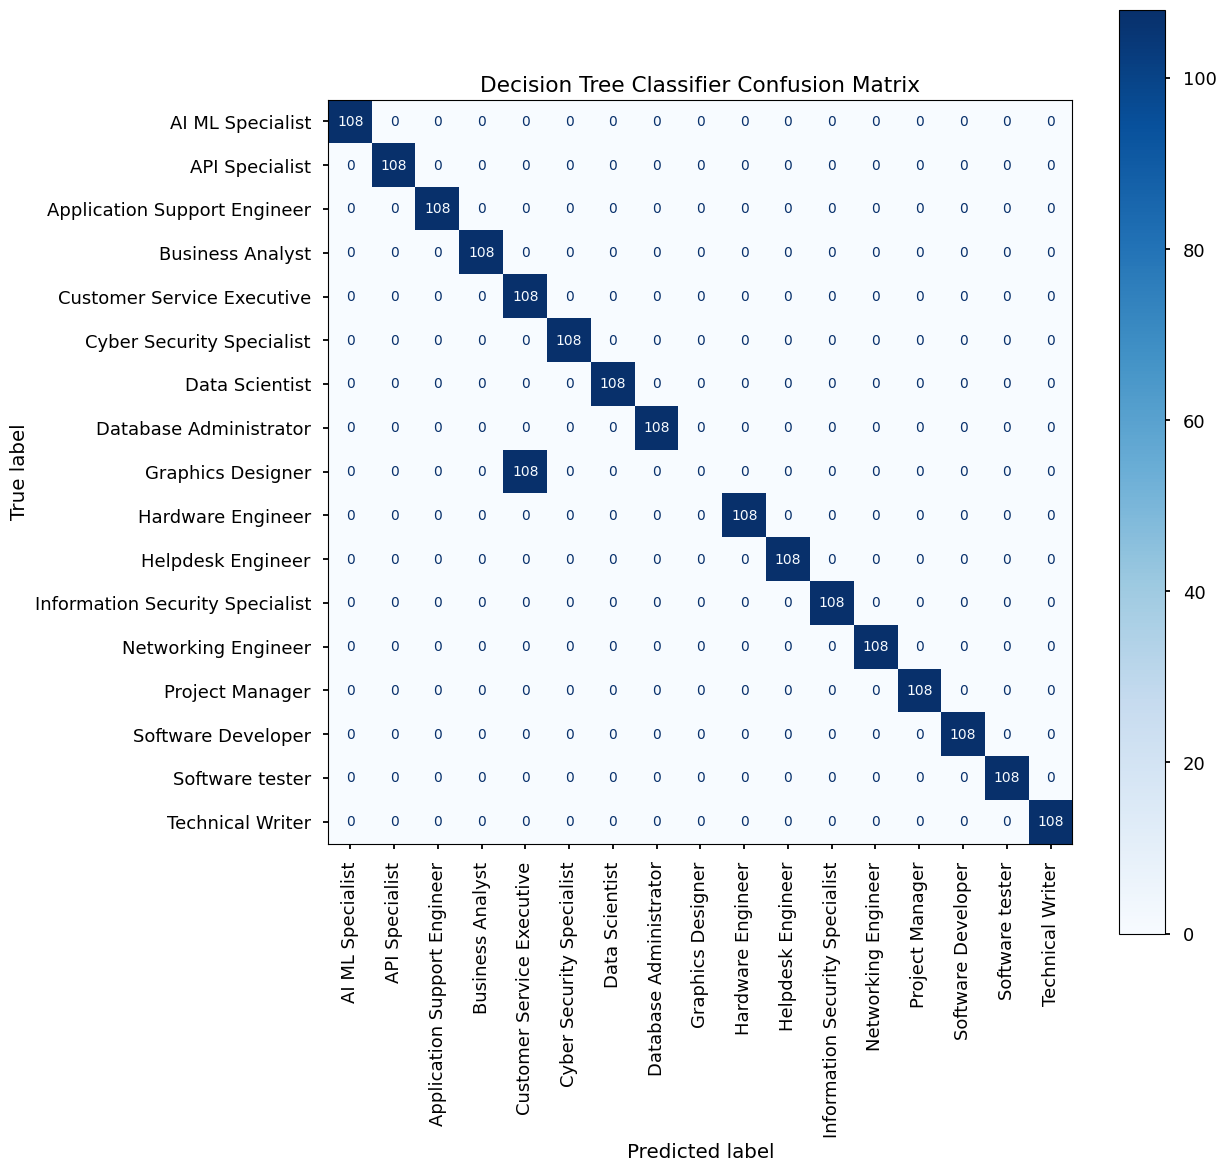

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))
ConfusionMatrixDisplay.from_estimator(dt_model, X_test, y_test, display_labels=role_labels, xticks_rotation='vertical', cmap=plt.cm.Blues, ax=ax)
plt.title("Decision Tree Classifier Confusion Matrix")
plt.show()

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=role_labels))


Classification Report:
                                 precision    recall  f1-score   support

               AI ML Specialist       1.00      1.00      1.00       108
                 API Specialist       1.00      1.00      1.00       108
   Application Support Engineer       1.00      1.00      1.00       108
               Business Analyst       1.00      1.00      1.00       108
     Customer Service Executive       0.50      1.00      0.67       108
      Cyber Security Specialist       1.00      1.00      1.00       108
                 Data Scientist       1.00      1.00      1.00       108
         Database Administrator       1.00      1.00      1.00       108
              Graphics Designer       0.00      0.00      0.00       108
              Hardware Engineer       1.00      1.00      1.00       108
              Helpdesk Engineer       1.00      1.00      1.00       108
Information Security Specialist       1.00      1.00      1.00       108
            Networking Eng

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


KNN

In [ ]:
print("\n\n--- K-Nearest Neighbors (KNN) ---")
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train, y_train)




--- K-Nearest Neighbors (KNN) ---


KNeighborsClassifier(n_neighbors=7)

In [ ]:
y_pred_knn = knn_model.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
model_accuracies['KNN (k=7)'] = accuracy_knn
print(f"Accuracy: {accuracy_knn:.4f}")

Accuracy: 0.9319


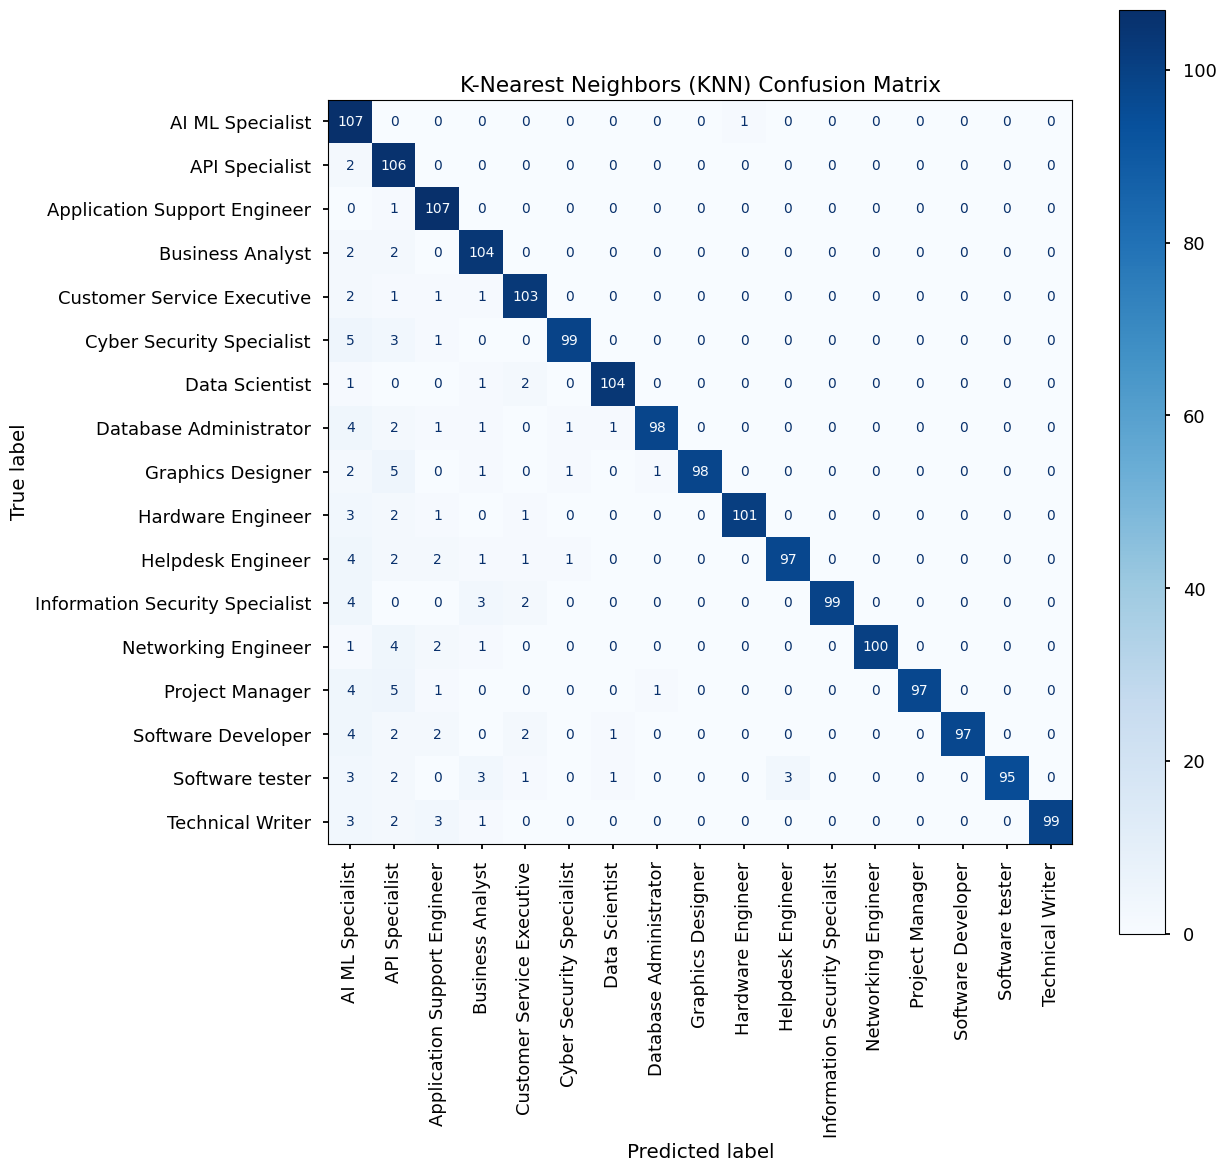

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))
ConfusionMatrixDisplay.from_estimator(knn_model, X_test, y_test, display_labels=role_labels, xticks_rotation='vertical', cmap=plt.cm.Blues, ax=ax)
plt.title("K-Nearest Neighbors (KNN) Confusion Matrix")
plt.show()

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=role_labels))




Classification Report:
                                 precision    recall  f1-score   support

               AI ML Specialist       0.71      0.99      0.83       108
                 API Specialist       0.76      0.98      0.86       108
   Application Support Engineer       0.88      0.99      0.93       108
               Business Analyst       0.89      0.96      0.92       108
     Customer Service Executive       0.92      0.95      0.94       108
      Cyber Security Specialist       0.97      0.92      0.94       108
                 Data Scientist       0.97      0.96      0.97       108
         Database Administrator       0.98      0.91      0.94       108
              Graphics Designer       1.00      0.91      0.95       108
              Hardware Engineer       0.99      0.94      0.96       108
              Helpdesk Engineer       0.97      0.90      0.93       108
Information Security Specialist       1.00      0.92      0.96       108
            Networking Eng

SVM

In [ ]:
print("\n\n--- SVM (Polynomial Kernel) ---")
svc_poly_model = SVC(kernel='poly', C=1,degree=6, random_state=999)
svc_poly_model.fit(X_train, y_train)




--- SVM (Polynomial Kernel) ---


SVC(C=1, degree=6, kernel='poly', random_state=999)

In [ ]:
y_pred_svc_poly = svc_poly_model.predict(X_test)
accuracy_svc_poly = accuracy_score(y_test, y_pred_svc_poly)
model_accuracies['SVM (Poly)'] = accuracy_svc_poly
print(f"Accuracy: {accuracy_svc_poly:.4f}")


Accuracy: 0.9989


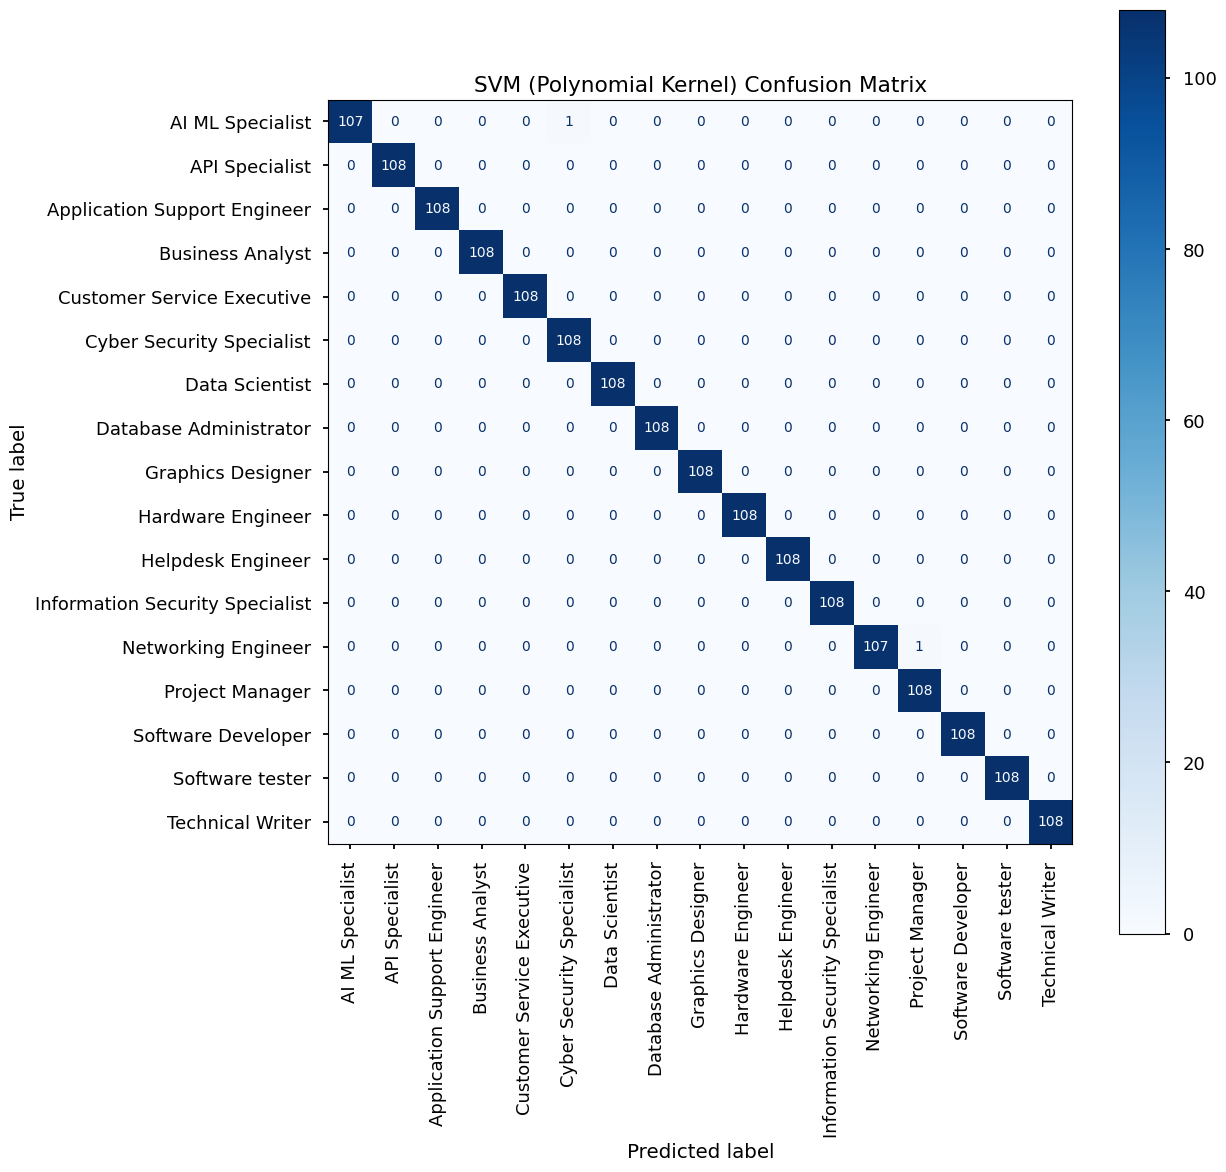

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))
ConfusionMatrixDisplay.from_estimator(svc_poly_model, X_test, y_test, display_labels=role_labels, xticks_rotation='vertical', cmap=plt.cm.Blues, ax=ax)
plt.title("SVM (Polynomial Kernel) Confusion Matrix")
plt.show()

Random Forest



--- Random Forest ) ---
Accuracy: 0.8235


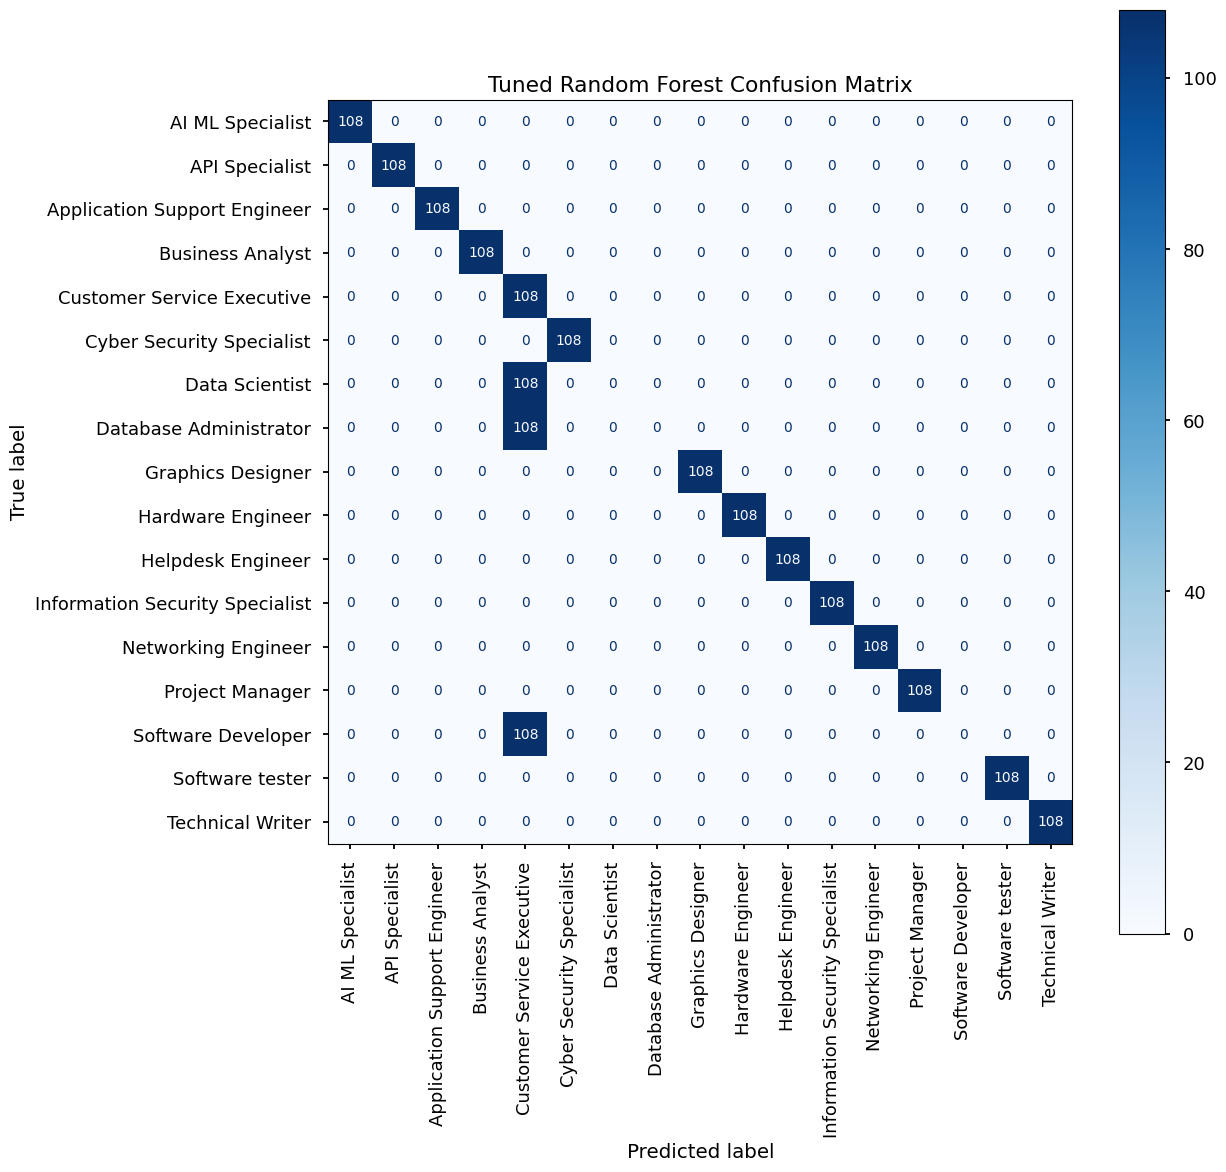


Classification Report:
                                 precision    recall  f1-score   support

               AI ML Specialist       1.00      1.00      1.00       108
                 API Specialist       1.00      1.00      1.00       108
   Application Support Engineer       1.00      1.00      1.00       108
               Business Analyst       1.00      1.00      1.00       108
     Customer Service Executive       0.25      1.00      0.40       108
      Cyber Security Specialist       1.00      1.00      1.00       108
                 Data Scientist       0.00      0.00      0.00       108
         Database Administrator       0.00      0.00      0.00       108
              Graphics Designer       1.00      1.00      1.00       108
              Hardware Engineer       1.00      1.00      1.00       108
              Helpdesk Engineer       1.00      1.00      1.00       108
Information Security Specialist       1.00      1.00      1.00       108
            Networking Eng

In [ ]:

print("\n\n--- Random Forest ) ---")


tuned_rf_model = RandomForestClassifier(n_estimators=10, max_depth=2, random_state=999)
tuned_rf_model.fit(X_train, y_train)

# Make predictions and calculate accuracy
y_pred_tuned_rf = tuned_rf_model.predict(X_test)
accuracy_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)
model_accuracies['Tuned Random Forest'] = accuracy_tuned_rf
print(f"Accuracy: {accuracy_tuned_rf:.4f}")

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 12))
ConfusionMatrixDisplay.from_estimator(
    tuned_rf_model,
    X_test,
    y_test,
    display_labels=role_labels,
    xticks_rotation='vertical',
    cmap=plt.cm.Blues,
    ax=ax
)
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned_rf, target_names=role_labels, zero_division=0))

Compare Accuracies



--- Final Model Accuracy Comparison ---


/tmp/ipython-input-6049058.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=accuracies_df.index, y=accuracies_df.values, palette='viridis')


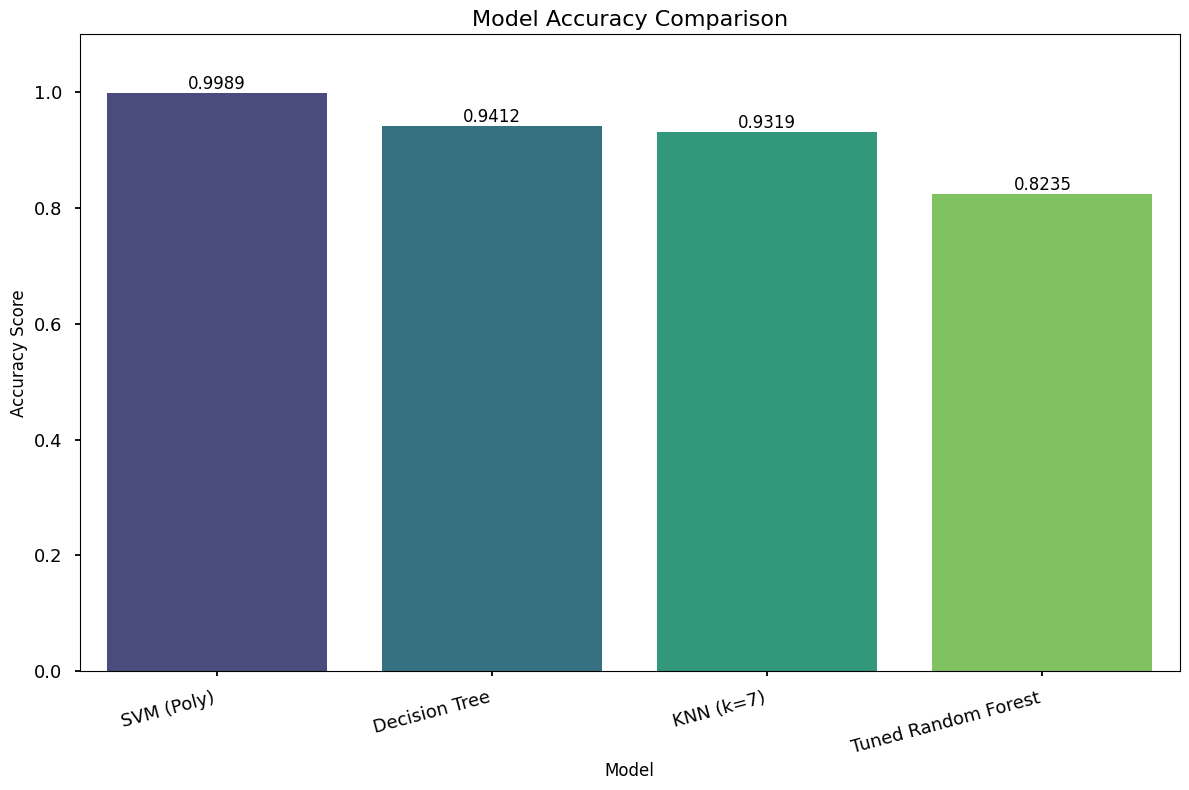


Final Accuracy Scores:
SVM (Poly)             0.998911
Decision Tree          0.941176
KNN (k=7)              0.931917
Tuned Random Forest    0.823529
dtype: float64


In [ ]:
print("\n\n--- Final Model Accuracy Comparison ---")
# Convert accuracy dictionary to a pandas Series for easy plotting
accuracies_df = pd.Series(model_accuracies).sort_values(ascending=False)

# Create the bar plot
plt.figure(figsize=(12, 8))
bars = sns.barplot(x=accuracies_df.index, y=accuracies_df.values, palette='viridis')
plt.title('Model Accuracy Comparison', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 1.1) # Set y-axis limit

# Add the accuracy values on top of each bar
for bar in bars.patches:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0,
        yval,
        f'{yval:.4f}',
        va='bottom',
        ha='center',
        fontsize=12
    )

plt.tight_layout()
plt.show()

print("\nFinal Accuracy Scores:")
print(accuracies_df)

In [ ]:
from sklearn.metrics import accuracy_score


y_pred_svc = svc_poly_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred_svc)

print(f"The model's accuracy on the test data is: {accuracy:.4f}")

The model's accuracy on the test data is: 0.9989


SHAP

In [ ]:
pip install shap

In [ ]:
import shap
import numpy as np

In [ ]:
explainer=shap.TreeExplainer(tuned_rf_model)
shap_values=explainer.shap_values(X_test)

In [ ]:
import numpy as np

print(np.array(shap_values).shape)
print(X_test.shape)
print(type(shap_values))


(1836, 17, 17)
(1836, 17)
<class 'numpy.ndarray'>


In [ ]:
print(np.array(shap_values).shape)

(1836, 17, 17)


In [ ]:
preds = tuned_rf_model.predict(X_test)
shap_values_class=np.array([shap_values[i,preds[i],:]
                            for i in range(len(preds))])
print(shap_values_class.shape)

NameError: name 'tuned_rf_model' is not defined

Global feature Importance


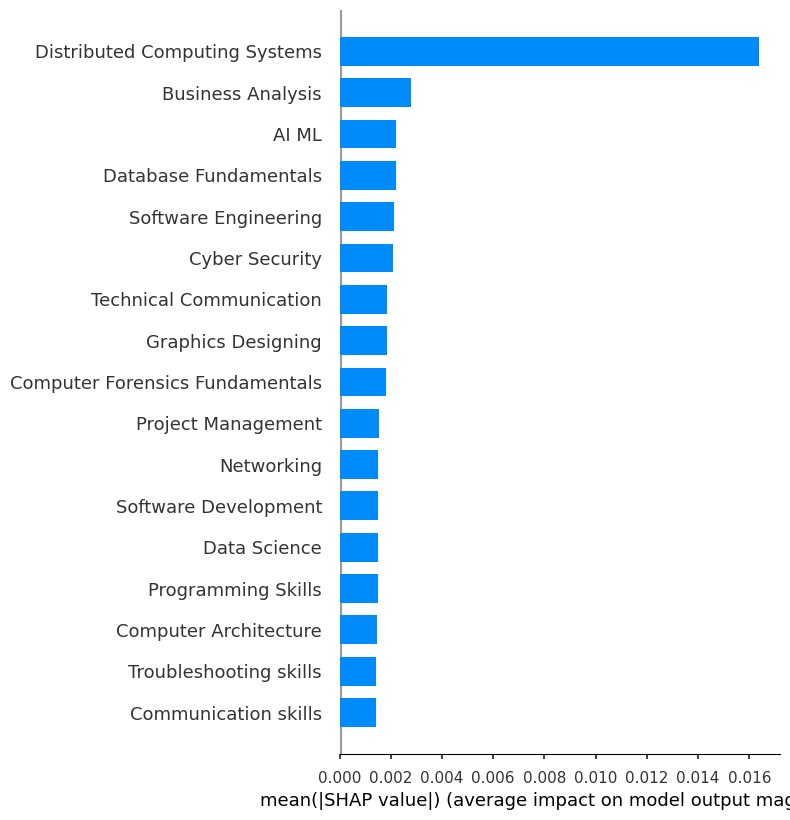

In [ ]:

print("Global feature Importance")
shap.summary_plot(shap_values_class, X_test,feature_names=X_test.columns, plot_type='bar')

In [ ]:

import matplotlib_inline
sample=X_test.iloc[[0]]
sample_shap=shap_values_class[0]
print(sample.shape)
print(sample_shap.shape)


(1, 17)
(17,)


/usr/local/lib/python3.12/dist-packages/shap/plots/_force_matplotlib.py:325: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(min_x, max_x)


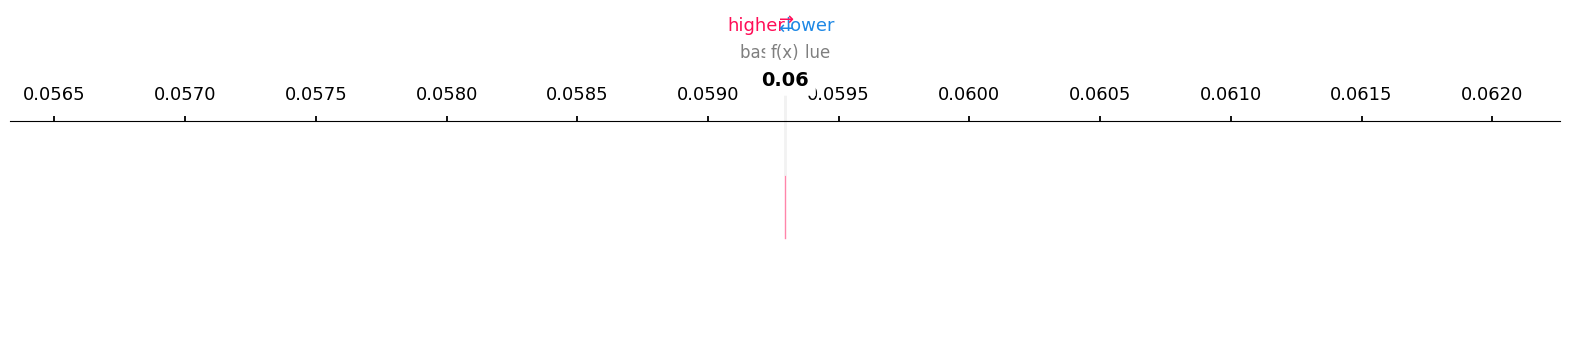

In [ ]:
shap.force_plot(explainer.expected_value[0],sample_shap,sample,matplotlib=True)

In [ ]:
print(role_labels)
print(len)

['AI ML Specialist' 'API Specialist' 'Application Support Engineer'
 'Business Analyst' 'Customer Service Executive'
 'Cyber Security Specialist' 'Data Scientist' 'Database Administrator'
 'Graphics Designer' 'Hardware Engineer' 'Helpdesk Engineer'
 'Information Security Specialist' 'Networking Engineer' 'Project Manager'
 'Software Developer' 'Software tester' 'Technical Writer']
<built-in function len>


In [ ]:
for i, labels in enumerate(role_labels):
    print(f"Class {i}: {labels}")

Class 0: AI ML Specialist
Class 1: API Specialist
Class 2: Application Support Engineer
Class 3: Business Analyst
Class 4: Customer Service Executive
Class 5: Cyber Security Specialist
Class 6: Data Scientist
Class 7: Database Administrator
Class 8: Graphics Designer
Class 9: Hardware Engineer
Class 10: Helpdesk Engineer
Class 11: Information Security Specialist
Class 12: Networking Engineer
Class 13: Project Manager
Class 14: Software Developer
Class 15: Software tester
Class 16: Technical Writer


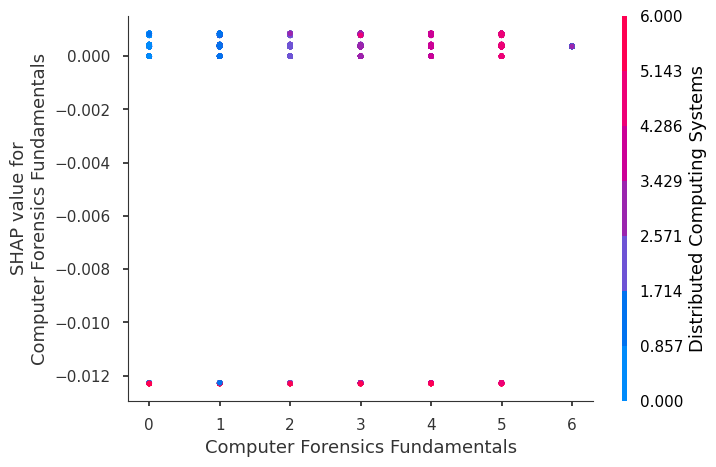

In [ ]:
feature_name=X_test.columns[8]
if isinstance(shap_values,list):
  shap.dependence_plot(feature_name, shap_values_class, X_test, feature_names=X_test.columns)
else:
  shap.dependence_plot(feature_name, shap_values_class, X_test, feature_names=X_test.columns)

In [ ]:
import joblib

In [ ]:

joblib.dump(tuned_rf_model,"models/carrer_predictor.pkl")

In [ ]:
joblib.dump(encoder,"encoder.pkl")